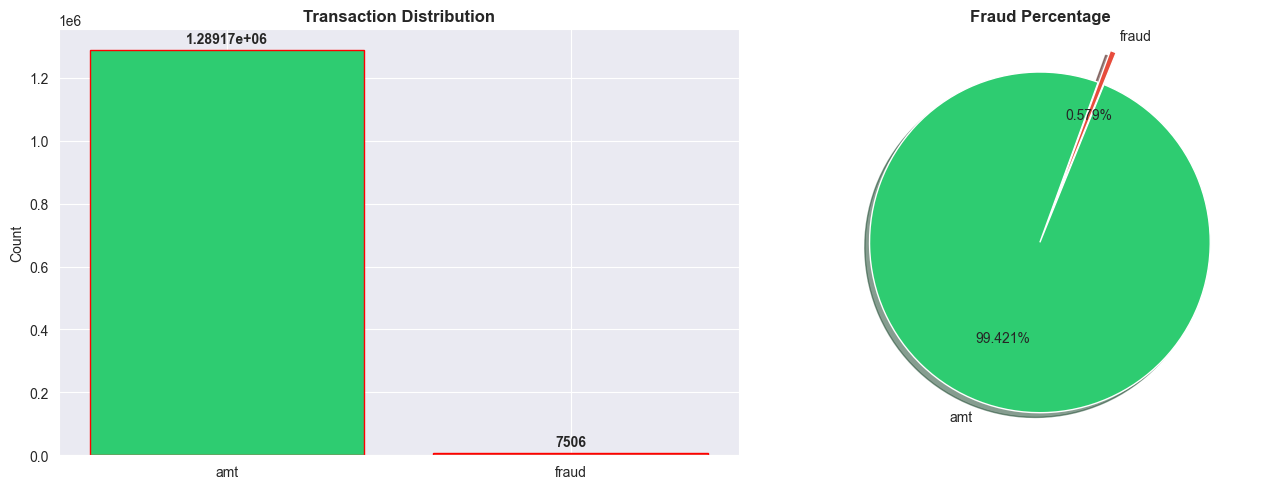

风险评估系数为 0.58%


In [4]:
# 该notebook主要分为数据可视化(分别结合CDA2级教材第5章数据可视化，主要分为matplotlib库和seaborn库)
#导入必备的库
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

train_df=pd.read_csv(r"C:\Users\范彬\OneDrive\桌面\train.csv")  #同上文引用train_dict变量
# 结合CDA2级教程5.2描述性统计分析思维进行数据探索
# 这里思路借鉴了AUro15kaggle上公开笔记本中的探索分析并加以修改,这里进行风险评估模型相关的风险系数计算
# 一.对主属性(is_fraud)进行单独分析
# 1. 准备数据
labels = ['amt', 'fraud'] # List format for plotting
colors = ['#2ecc71', '#e74c3c']
fraud_counts=train_df["is_fraud"].value_counts()#设置风险统计数
fraud_rate=train_df["is_fraud"].mean()#设置风险评估系数
# 2. 设置分窗图布局
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左边图表:条形图
bars = axes[0].bar(labels, fraud_counts, color=colors, edgecolor='red')
axes[0].set_title('Transaction Distribution', fontweight='bold', fontsize=12)
axes[0].bar_label(bars, padding=3, fontweight='bold')
axes[0].set_ylabel('Count')

# 右边图表:饼图
axes[1].pie(fraud_counts, labels=labels, autopct='%1.3f%%', colors=colors,
            startangle=70, explode=(0, 0.2), shadow=True)
axes[1].set_title('Fraud Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"风险评估系数为 {fraud_rate:.2%}")

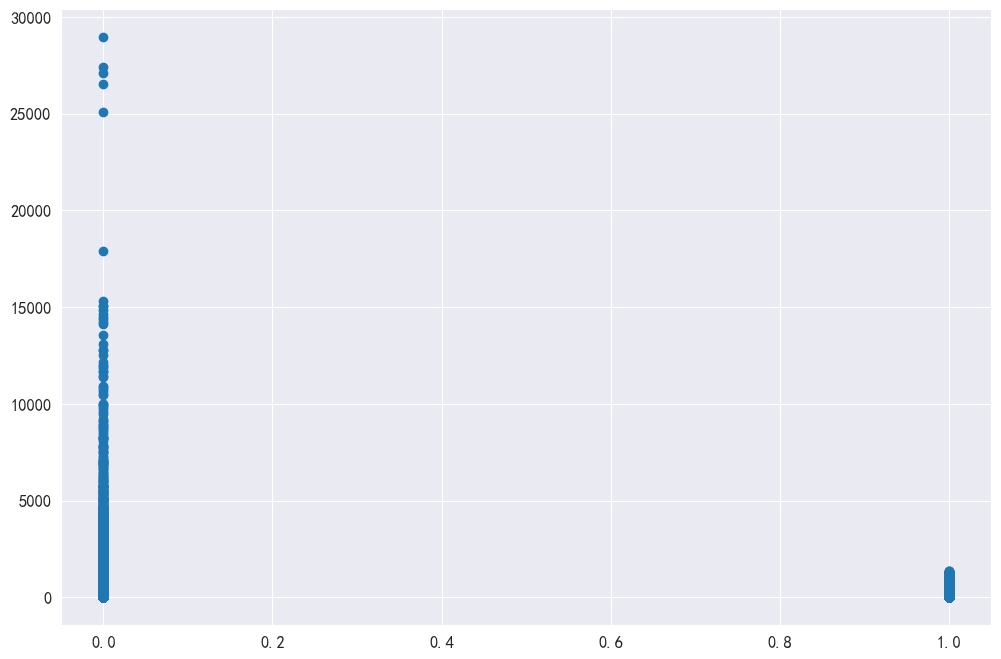

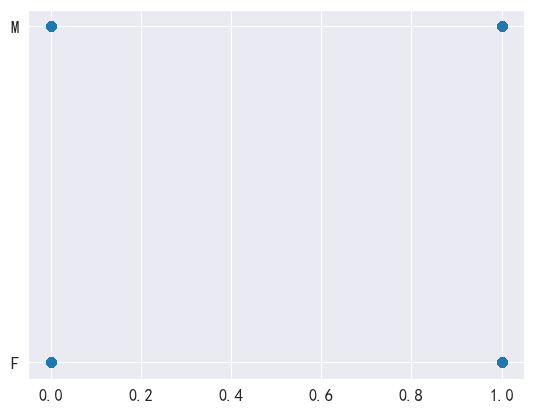

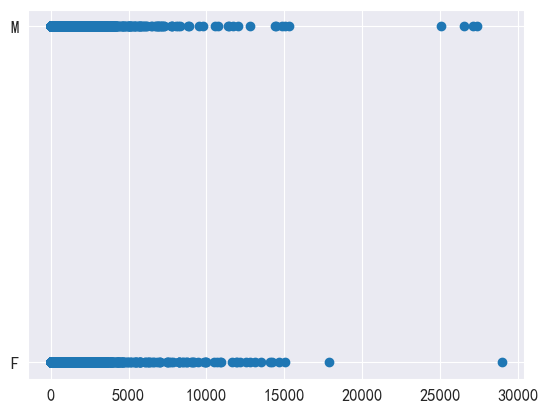

In [5]:
#接下来根据amt和is_fraud变量结合CDA2级第5章2个数据库(matplotlib库及seaborn库进行双变量关系分析)
# 二.对可能影响主属性的相关变量进行相关性分析,分为amt(金额)和gender(性别)对is_fraud影响和amt与gender相关性
#首先使用5.1.1matplotlib库中散点图进行相关性数据可视化
#相关图表属性配置
plt.rcParams['font.size'] = 12#调节字体大小
plt.rcParams["font.sans-serif"] = ['SimHei']#显示中文
plt.rcParams['axes.unicode_minus'] = False#避免符号显示干扰
plt.figure(figsize=(12, 8))#设置图表布局
#变量相关性数据可视化分析,下面使用matplotlib中散点图,seaborn库中的联合图，带核密度的联合图进行单独分析

#这里使用matplotlib库中的散点图
#先探索amt(金额)和is_fraud(欺诈值)关系_
plt.scatter(train_df["is_fraud"],train_df["amt"])
plt.show()
#接下来探索gender(性别)和is_fraud(欺诈值)关系_
plt.scatter(train_df["is_fraud"],train_df["gender"])
plt.show()
#这时候发现两者关系不够明显，优化环境同时分析gender和amt关系,因为amt和is_fraud明显呈现反比例关系
plt.scatter(train_df["amt"],train_df["gender"])
plt.show()

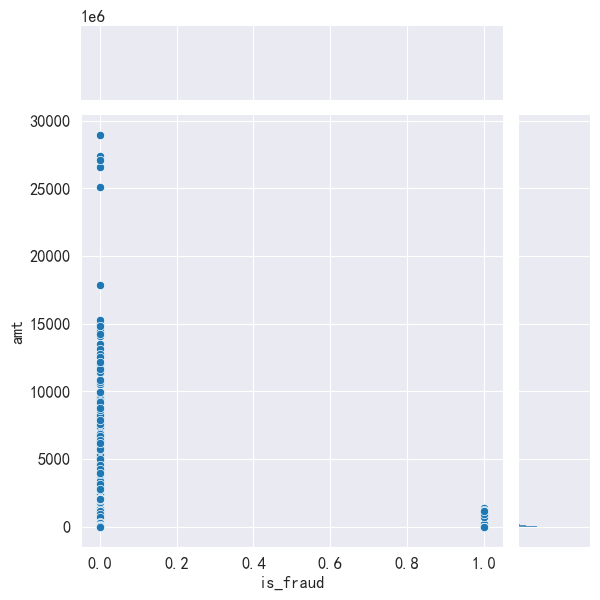

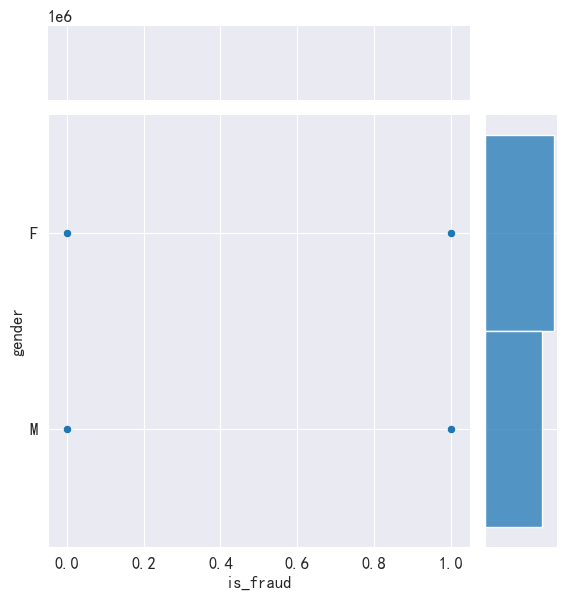

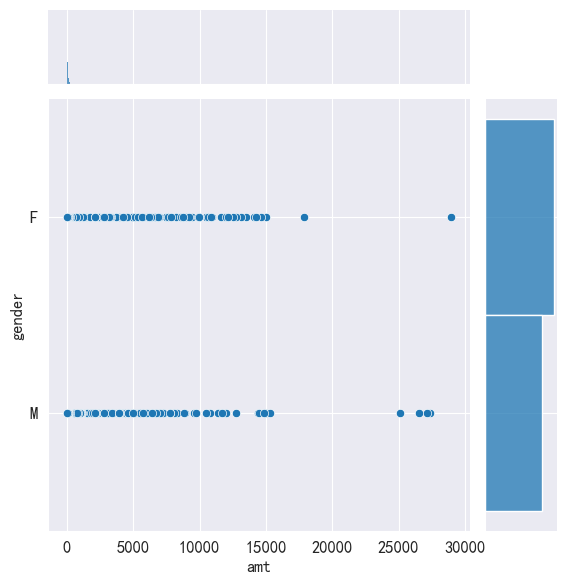

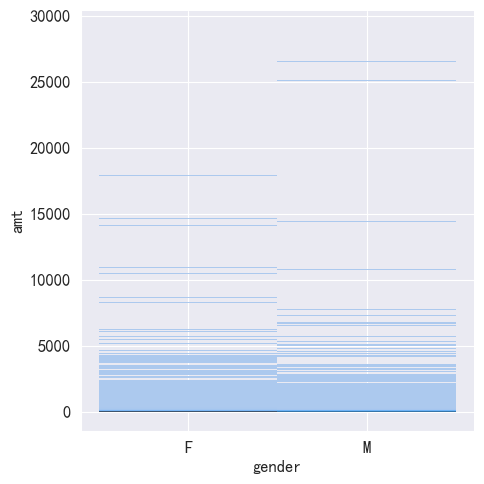

In [6]:
#结果很明显,没有明显的数据可视化效果,于是转向seaborn库中的联合图
sns.jointplot(x="is_fraud",y="amt",data=train_df)
plt.show()
sns.jointplot(x="is_fraud",y="gender",data=train_df)
plt.show()
sns.jointplot(x="amt",y="gender",data=train_df)
plt.show()
#可视化效果得到有效提高，但明显amt和gender有更好的可视化效果

#接下来针对amt和gender进行添加带核密度估计的联合分布图
sns.displot(data=train_df,x="gender",y="amt")
plt.show()


<Figure size 1200x800 with 0 Axes>

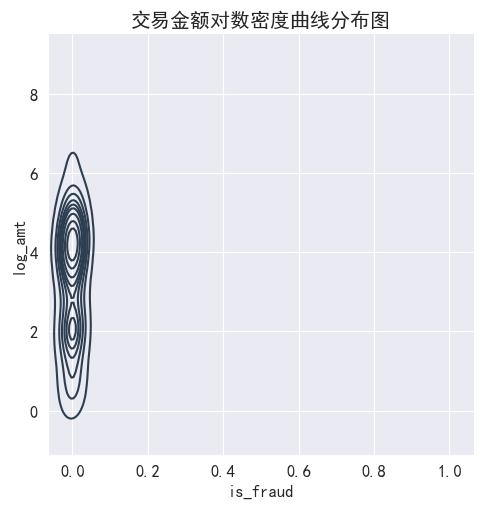

In [8]:
#接下来观察变量分布情况
#密度曲线图图再次查看amt变量的分布(结合CDA5.1。2seaborn库内容)
# 由于样本集体量较大(超过1000000行),故经过查询资料使用sample抽样法
sampled_df=train_df.sample(n=2595,random_state=42)
#鉴于amt分布较为不均,因此使用取对数法进行优化
sampled_df["log_amt"]=np.log(sampled_df["amt"])
plt.figure(figsize=(12, 8))
sns.displot(data=sampled_df,x="is_fraud",y="log_amt",color="#2c3e50",kind="kde")
plt.title("交易金额对数密度曲线分布图")
plt.show()